# Gaussian noise sigma sweep


        This notebook calls the standalone Gaussian function across the
        validated sigma range `[0.01, 0.25]`. Every panel resets the same random
        seed so changes are attributable to sigma. The function returns raw
        values; panels use a fixed `[0, 1]` display window only.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "denoiselearn").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the denoise-learn checkout.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

MASTER_SEED = 20260724
plt.rcParams.update({"figure.dpi": 90, "savefig.dpi": 90})
print("Repository root located: PASS")
print(f"Master seed: {MASTER_SEED}")

Repository root located: PASS
Master seed: 20260724


In [2]:
def synthetic_atomic_image(size: int = 128) -> torch.Tensor:
    yy, xx = np.mgrid[:size, :size]
    image = np.full((size, size), 0.015, dtype=np.float32)
    for row, y in enumerate(range(12, size - 11, 16)):
        for column, x in enumerate(range(12, size - 11, 16)):
            amplitude = 0.70 if (row + column) % 2 else 1.00
            image += amplitude * np.exp(
                -0.5 * ((yy - y) ** 2 + (xx - x) ** 2) / 2.1**2
            ).astype(np.float32)
    image -= float(image.min())
    image /= float(image.max())
    return torch.from_numpy(image)


clean = synthetic_atomic_image()
assert clean.dtype == torch.float32
assert clean.shape == (128, 128)
assert float(clean.min()) == 0.0
assert float(clean.max()) == 1.0

In [3]:
from denoiselearn.noise import (
    GAUSSIAN_SIGMA_RANGE,
    add_gaussian_noise,
)

sigma_values = [0.01, 0.07, 0.13, 0.19, 0.25]
assert sigma_values[0] == GAUSSIAN_SIGMA_RANGE[0]
assert sigma_values[-1] == GAUSSIAN_SIGMA_RANGE[1]

first, first_metadata = add_gaussian_noise(
    clean, sigma=0.13, rng=np.random.default_rng(MASTER_SEED)
)
second, second_metadata = add_gaussian_noise(
    clean, sigma=0.13, rng=np.random.default_rng(MASTER_SEED)
)
assert torch.equal(first, second)
assert first_metadata == second_metadata
print("Fixed-seed reproducibility: PASS")

Fixed-seed reproducibility: PASS


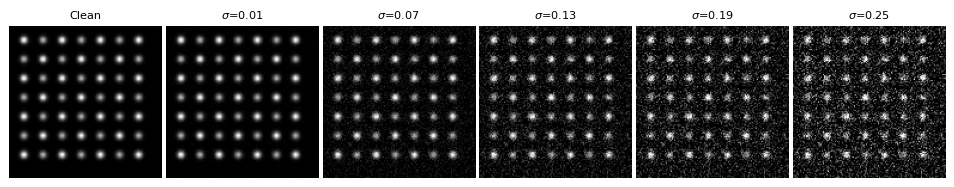

$\sigma$=0.01: realized std=0.0100, raw range=[-0.038, 1.016]
$\sigma$=0.07: realized std=0.0700, raw range=[-0.266, 1.115]
$\sigma$=0.13: realized std=0.1301, raw range=[-0.497, 1.214]
$\sigma$=0.19: realized std=0.1901, raw range=[-0.731, 1.313]
$\sigma$=0.25: realized std=0.2502, raw range=[-0.965, 1.425]


In [4]:
panels = [("Clean", clean, None)]
for sigma in sigma_values:
    noisy, metadata = add_gaussian_noise(
        clean,
        sigma=sigma,
        rng=np.random.default_rng(MASTER_SEED),
    )
    panels.append((f"$\\sigma$={sigma:.2f}", noisy, metadata))

figure, axes = plt.subplots(1, len(panels), figsize=(10.5, 2.05))
for axis, (title, image, _) in zip(axes, panels):
    axis.imshow(image.numpy(), cmap="gray", vmin=0.0, vmax=1.0)
    axis.set_title(title, fontsize=9)
    axis.axis("off")
figure.tight_layout(pad=0.35)
plt.show()

for title, _, metadata in panels[1:]:
    print(
        f"{title}: realized std={metadata['gaussian_realized_std']:.4f}, "
        f"raw range=[{metadata['post_gaussian_min']:.3f}, "
        f"{metadata['post_gaussian_max']:.3f}]"
    )